# AI-Driven Prediction of Power Grid Instability in Nigeria
### Full Implementation Notebook

**Goal:** Predict Nigerian 330 kV grid instability *T* steps before it occurs so
operators can take proactive corrective action before a system collapse.

**Pipeline:**
```
Data Input → Feature Engineering → Preprocessing → Prediction Model → Alert System
```

**Target labels**
| Label | Meaning | Frequency | Voltage |
|---|---|---|---|
| 0 | Stable | 49.5 – 50.5 Hz | ≥ 0.97 pu |
| 1 | Unstable / Warning | outside nominal band | 0.90 – 0.97 pu |
| 2 | Collapse / Blackout | < 48.5 Hz or > 51.5 Hz | < 0.80 pu |

**Models implemented:** Logistic Regression · Random Forest · XGBoost · LSTM


## 0 · Setup & Configuration

In [9]:
import os
import sys
import warnings
import pickle
import math
from collections import deque

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_recall_curve,
    average_precision_score
)
from sklearn.pipeline import Pipeline

# ── Optional dependencies ─────────────────────────────────────────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
    print(f"  XGBoost {xgb.__version__} ✓")
except ImportError:
    HAS_XGB = False
    print("  XGBoost not found  →  GradientBoostingClassifier used as fallback")
    print("  Install:  pip install xgboost")

try:
    from imblearn.over_sampling import BorderlineSMOTE
    HAS_IMBLEARN = True
    print("  imbalanced-learn ✓")
except ImportError:
    HAS_IMBLEARN = False
    print("  imbalanced-learn not found  →  class_weight='balanced' used instead")
    print("  Install:  pip install imbalanced-learn")

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import (
        LSTM, Dense, Dropout, BatchNormalization, Bidirectional
    )
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.utils import to_categorical
    HAS_TF = True
    print(f"  TensorFlow {tf.__version__} ✓")
    tf.random.set_seed(42)
except ImportError:
    HAS_TF = False
    print("  TensorFlow not found  →  LSTM section will be skipped")
    print("  Install:  pip install tensorflow")

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})
PALETTE = {"Stable": "#2ecc71", "Unstable": "#f39c12", "Collapse": "#e74c3c"}
CLASS_COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]
LABEL_NAMES  = ["Stable", "Unstable", "Collapse"]

# ── Configuration: edit paths here if needed ──────────────────────────────────
DATA_DIR       = r"."            # folder containing the CSVs
CSV_AUG        = "https://raw.githubusercontent.com/Okwybobby/AI-Driven-Prediction-of-Power-Grid-Instability/refs/heads/main/nigeria_grid_stability_main.csv"
CSV_SEED       = "https://raw.githubusercontent.com/Okwybobby/AI-Driven-Prediction-of-Power-Grid-Instability/refs/heads/main/nigeria_grid_stability_dataset.csv"
FIGURES_DIR    = os.path.join(DATA_DIR, "figures")
MODEL_DIR      = os.path.join(DATA_DIR, "models")
for d in (FIGURES_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

# LSTM / sequence parameters
LSTM_WINDOW    = 20    # steps in each input sequence  (20 × 0.1 s = 2 s of history)
T_HORIZON      = 5     # predict state this many steps ahead of the window end
                       # at 0.1 s/step  →  0.5 s early warning
                       # at 60 s/step (daily cycle)  →  5 min early warning
RANDOM_STATE   = 42
np.random.seed(RANDOM_STATE)
# ──────────────────────────────────────────────────────────────────────────────
print("\n[0] Setup complete.")

  XGBoost 3.2.0 ✓
  imbalanced-learn ✓
  TensorFlow 2.20.0 ✓

[0] Setup complete.


## 1 · Data Loading & Validation

In [12]:
# ── Load Main (primary training) dataset ─────────────────────────────────
df = pd.read_csv(CSV_AUG)
print(f"Main dataset : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Load seed (research validation) dataset ───────────────────────────────────
df_seed = pd.read_csv(CSV_SEED)
print(f"Seed dataset      : {df_seed.shape[0]:,} rows × {df_seed.shape[1]} columns")

# ── Schema check ──────────────────────────────────────────────────────────────
REQUIRED = ["Frequency_Hz", "Voltage_pu", "Angle_deg",
            "Active_Power_MW", "Reactive_Power_MVAr",
            "ROCOF_Hz_per_s", "Ambient_Temp_C", "Stability_Label"]
missing = [c for c in REQUIRED if c not in df.columns]
assert not missing, f"Missing columns in Main CSV: {missing}"
print(f"\nAll {len(REQUIRED)} required columns present  ✓")

# ── Null / NaN audit ──────────────────────────────────────────────────────────
null_counts = df[REQUIRED].isnull().sum()
if null_counts.sum() == 0:
    print("No null values found  ✓")
else:
    print("Null values detected: filling with column medians:")
    for col in REQUIRED[:-1]:          # skip label
        df[col].fillna(df[col].median(), inplace=True)

# ── Quick summary ─────────────────────────────────────────────────────────────
print("\n── Main dataset statistics ──")
print(df[REQUIRED[:-1]].describe().round(3).to_string())

print("\n── Label distribution ──")
vc = df["Stability_Label"].value_counts().sort_index()
for lbl, cnt in vc.items():
    print(f"  {lbl} ({LABEL_NAMES[lbl]:9s}): {cnt:6,}  ({100*cnt/len(df):.1f}%)")

Augmented dataset : 11,510 rows × 16 columns
Seed dataset      : 123 rows × 17 columns

All 8 required columns present  ✓
No null values found  ✓

── Augmented dataset statistics ──
       Frequency_Hz  Voltage_pu  Angle_deg  Active_Power_MW  Reactive_Power_MVAr  ROCOF_Hz_per_s  Ambient_Temp_C
count     11510.000   11510.000  11510.000        11510.000            11510.000       11510.000       11510.000
mean         48.576       0.923     29.037          421.557              253.440          -0.130          32.061
std           7.257       0.210     37.132          153.024               91.998           0.882           4.595
min           0.000       0.000   -113.240            0.000                0.000          -4.979          21.000
25%          49.667       0.965     11.535          345.540              207.739          -0.500          28.000
50%          49.930       0.992     23.860          429.086              257.966          -0.053          33.100
75%          50.092       1

## 2 · Exploratory Data Analysis (EDA)

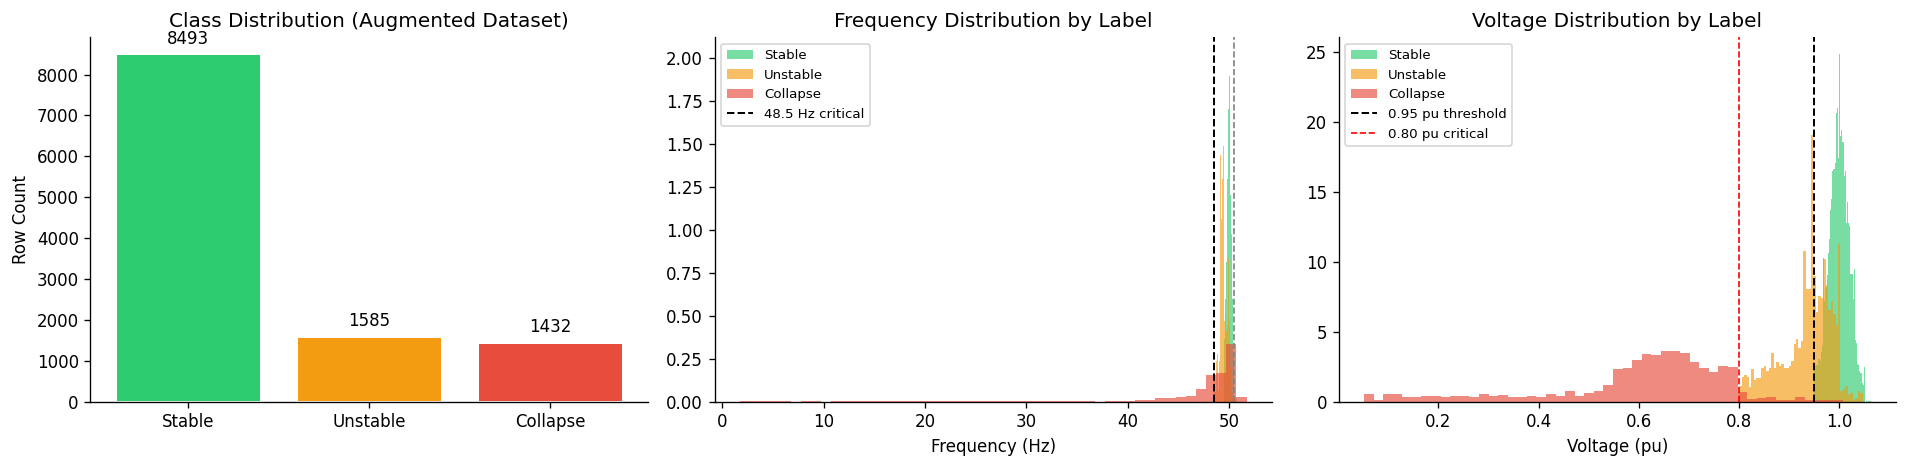

In [13]:
# ── 2.1  Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart: label counts
counts = df["Stability_Label"].value_counts().sort_index()
bars = axes[0].bar(LABEL_NAMES, counts.values,
                   color=CLASS_COLORS, edgecolor="white", linewidth=1.2)
axes[0].bar_label(bars, fmt="%d", padding=4)
axes[0].set_title("Class Distribution (Main Dataset)")
axes[0].set_ylabel("Row Count")

# Frequency distribution by label
for lbl, name, col in zip([0, 1, 2], LABEL_NAMES, CLASS_COLORS):
    subset = df[df["Stability_Label"] == lbl]["Frequency_Hz"]
    subset = subset[subset > 0]          # exclude collapse zeros for visibility
    axes[1].hist(subset, bins=50, alpha=0.65, color=col, label=name, density=True)
axes[1].axvline(48.5, color="black", ls="--", lw=1.2, label="48.5 Hz critical")
axes[1].axvline(50.5, color="grey",  ls="--", lw=1.0)
axes[1].set_title("Frequency Distribution by Label")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].legend(fontsize=8)

# Voltage distribution by label
for lbl, name, col in zip([0, 1, 2], LABEL_NAMES, CLASS_COLORS):
    subset = df[df["Stability_Label"] == lbl]["Voltage_pu"]
    subset = subset[subset > 0.05]
    axes[2].hist(subset, bins=50, alpha=0.65, color=col, label=name, density=True)
axes[2].axvline(0.95, color="black", ls="--", lw=1.2, label="0.95 pu threshold")
axes[2].axvline(0.80, color="red",   ls="--", lw=1.0, label="0.80 pu critical")
axes[2].set_title("Voltage Distribution by Label")
axes[2].set_xlabel("Voltage (pu)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_class_and_feature_distributions.png"))
plt.show()

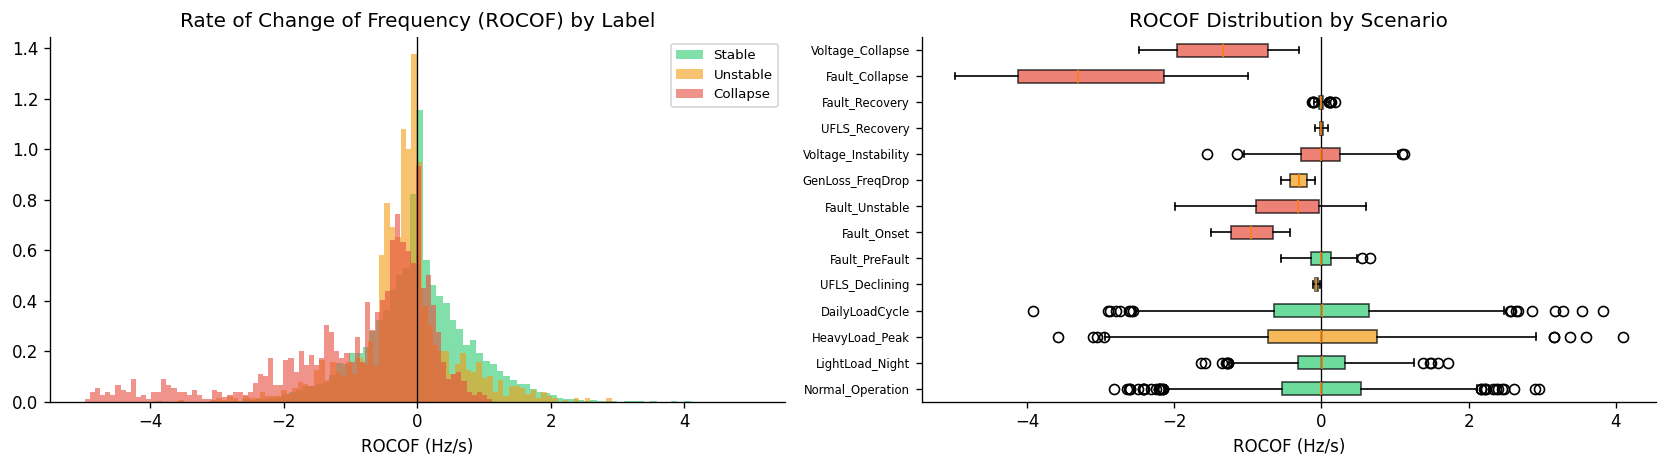

In [14]:
# ── 2.2  ROCOF: the primary early-warning feature ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ROCOF histogram
for lbl, name, col in zip([0, 1, 2], LABEL_NAMES, CLASS_COLORS):
    subset = df[df["Stability_Label"] == lbl]["ROCOF_Hz_per_s"]
    axes[0].hist(subset, bins=80, alpha=0.6, color=col, label=name, density=True)
axes[0].set_xlim(-5.5, 5.5)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Rate of Change of Frequency (ROCOF) by Label")
axes[0].set_xlabel("ROCOF (Hz/s)")
axes[0].legend(fontsize=8)

# Boxplot: ROCOF by scenario type
scenario_order = [
    "Normal_Operation", "LightLoad_Night", "HeavyLoad_Peak",
    "DailyLoadCycle", "UFLS_Declining",
    "Fault_PreFault", "Fault_Onset", "Fault_Unstable",
    "GenLoss_FreqDrop", "Voltage_Instability",
    "UFLS_Recovery", "Fault_Recovery",
    "Fault_Collapse", "Voltage_Collapse"
]
plot_data = df[df["Scenario"].isin(scenario_order)].copy()
scen_labels = {s: df[df["Scenario"]==s]["Stability_Label"].mode()[0]
               for s in scenario_order if s in df["Scenario"].unique()}
box_colors = [CLASS_COLORS[scen_labels.get(s, 0)] for s in scenario_order]

bp = axes[1].boxplot(
    [df[df["Scenario"]==s]["ROCOF_Hz_per_s"].values
     for s in scenario_order if s in df["Scenario"].unique()],
    vert=False, patch_artist=True,
    labels=[s for s in scenario_order if s in df["Scenario"].unique()]
)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("ROCOF Distribution by Scenario")
axes[1].set_xlabel("ROCOF (Hz/s)")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_rocof_analysis.png"))
plt.show()

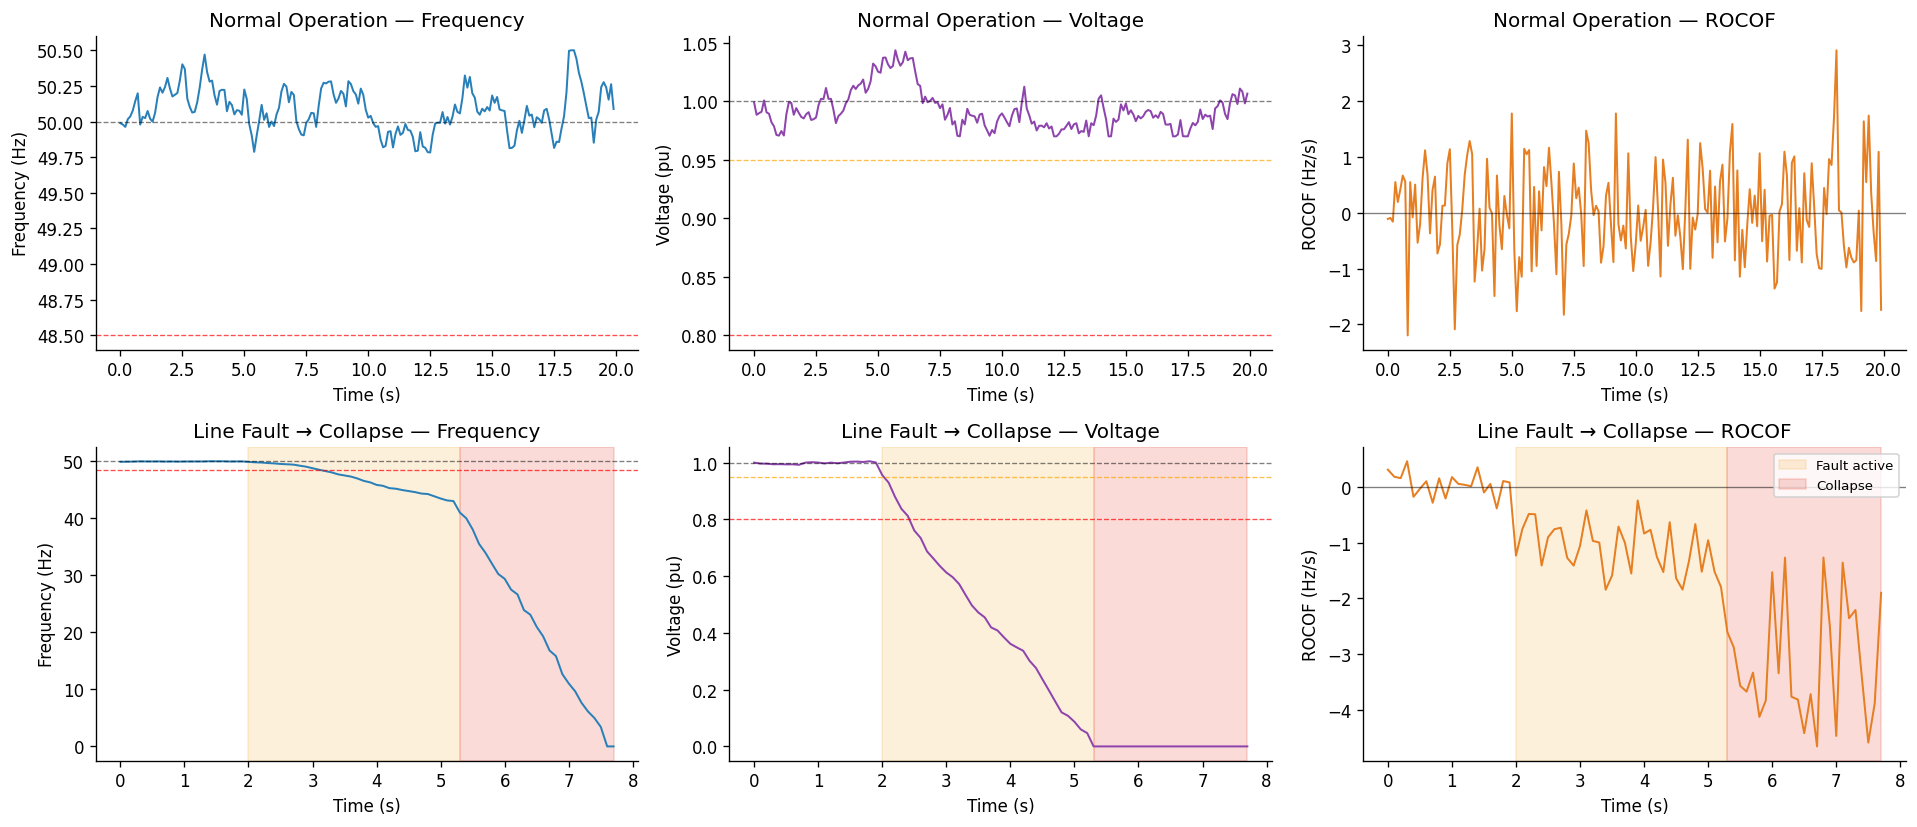

In [15]:
# ── 2.3  Sample time-series: Normal vs. Fault Collapse ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

normal = df[df["Scenario"] == "Normal_Operation"].head(200)
fault  = df[df["Scenario"].isin(
    ["Fault_PreFault","Fault_Onset","Fault_Unstable","Fault_Collapse"])
].iloc[:78]   # first fault event (20+8+25+25 steps)
fault  = fault.reset_index(drop=True)

for row_idx, (subset, title) in enumerate([(normal, "Normal Operation"),
                                            (fault,  "Line Fault → Collapse")]):
    t = subset["Sim_Time_s"].astype(float)
    col_bg = {0: "#d5f5e3", 1: "#fef9e7", 2: "#fdedec"}

    # Shade collapse region for fault plot
    if row_idx == 1:
        onset_t = fault[fault["Scenario"] == "Fault_Onset"]["Sim_Time_s"].min()
        col_t   = fault[fault["Scenario"] == "Fault_Collapse"]["Sim_Time_s"].min()
        for ax in axes[row_idx]:
            ax.axvspan(float(onset_t), float(col_t), alpha=0.15, color="#f39c12",
                       label="Fault active")
            ax.axvspan(float(col_t),   float(t.max()),  alpha=0.20, color="#e74c3c",
                       label="Collapse")

    axes[row_idx][0].plot(t, subset["Frequency_Hz"], color="#2980b9", lw=1.2)
    axes[row_idx][0].axhline(50.0, color="black", ls="--", lw=0.8, alpha=0.5)
    axes[row_idx][0].axhline(48.5, color="red",   ls="--", lw=0.8, alpha=0.7)
    axes[row_idx][0].set_ylabel("Frequency (Hz)")
    axes[row_idx][0].set_title(f"{title}: Frequency")

    axes[row_idx][1].plot(t, subset["Voltage_pu"], color="#8e44ad", lw=1.2)
    axes[row_idx][1].axhline(1.0,  color="black", ls="--", lw=0.8, alpha=0.5)
    axes[row_idx][1].axhline(0.95, color="orange",ls="--", lw=0.8, alpha=0.7)
    axes[row_idx][1].axhline(0.80, color="red",   ls="--", lw=0.8, alpha=0.7)
    axes[row_idx][1].set_ylabel("Voltage (pu)")
    axes[row_idx][1].set_title(f"{title}: Voltage")

    axes[row_idx][2].plot(t, subset["ROCOF_Hz_per_s"], color="#e67e22", lw=1.2)
    axes[row_idx][2].axhline(0, color="black", lw=0.8, alpha=0.5)
    axes[row_idx][2].set_ylabel("ROCOF (Hz/s)")
    axes[row_idx][2].set_title(f"{title}: ROCOF")

    for ax in axes[row_idx]:
        ax.set_xlabel("Time (s)")

if row_idx == 1:
    axes[1][2].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_timeseries_normal_vs_fault.png"))
plt.show()

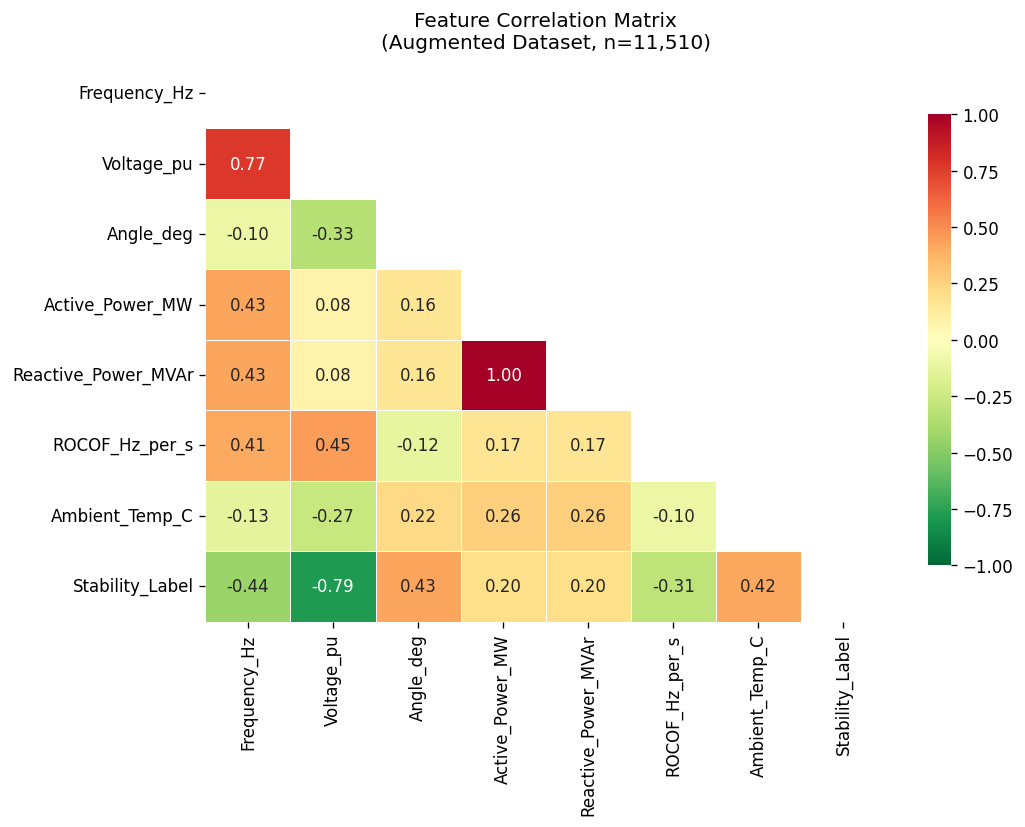

In [16]:
# ── 2.4  Feature correlation heatmap ─────────────────────────────────────────
NUMERIC_COLS = ["Frequency_Hz", "Voltage_pu", "Angle_deg",
                "Active_Power_MW", "Reactive_Power_MVAr",
                "ROCOF_Hz_per_s", "Ambient_Temp_C", "Stability_Label"]
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix\n(Main Dataset, n=11,510)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_correlation_heatmap.png"))
plt.show()

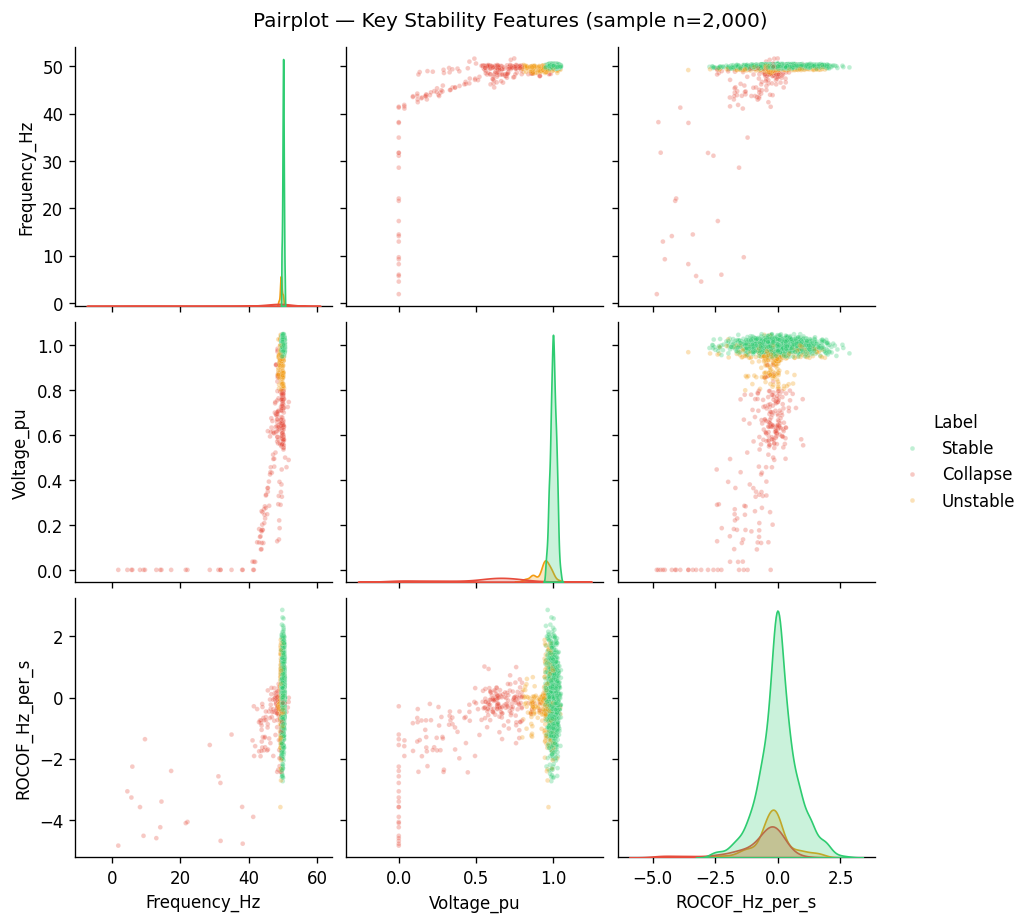

In [17]:
# ── 2.5  Pairplot of key stability features ───────────────────────────────────
pp_cols = ["Frequency_Hz", "Voltage_pu", "ROCOF_Hz_per_s", "Stability_Label"]
pp_df   = df[pp_cols].copy()
pp_df   = pp_df[pp_df["Frequency_Hz"] > 0]     # exclude zero-frequency collapse rows
pp_df["Label"] = pp_df["Stability_Label"].map(
    {0: "Stable", 1: "Unstable", 2: "Collapse"})

g = sns.pairplot(pp_df.drop(columns="Stability_Label").sample(2000, random_state=42),
                 hue="Label", palette=PALETTE,
                 plot_kws={"alpha": 0.3, "s": 8},
                 diag_kind="kde")
g.figure.suptitle("Pairplot: Key Stability Features (sample n=2,000)",
                  y=1.02, fontsize=12)
g.figure.savefig(os.path.join(FIGURES_DIR, "05_pairplot.png"),
                 bbox_inches="tight")
plt.show()

## 3 · Feature Engineering

Derived features that are strongly predictive of instability (Chapter 3: Feature Extraction):

| Feature | Formula | Rationale |
|---|---|---|
| `Freq_Dev` | \|f − 50\| | Distance from nominal; more informative than raw Hz |
| `V_Dev` | \|V − 1.0\| | Distance from nominal voltage |
| `Freq_sq` | Freq_Dev² | Penalty grows non-linearly near collapse |
| `V_sq` | V_Dev² | Same for voltage |
| `PQ_Ratio` | P / (Q + ε) | Power factor proxy; high Q demand = stressed |
| `Apparent_S` | √(P² + Q²) | Total apparent power |
| `Power_Factor` | P / (S + ε) | Low PF indicates reactive stress |
| `FxV` | f × V | Joint degradation feature |
| `ROCOF_abs` | \|ROCOF\| | Magnitude of frequency rate of change |
| `ROCOF_sq` | ROCOF² | Amplifies large ROCOF events |

In [18]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Add physics-informed engineered features to a grid dataset."""
    d = data.copy()
    eps = 1e-6

    # Distance-from-nominal features
    d["Freq_Dev"]    = (d["Frequency_Hz"] - 50.0).abs()
    d["V_Dev"]       = (d["Voltage_pu"] - 1.0).abs()
    d["Freq_sq"]     = d["Freq_Dev"] ** 2
    d["V_sq"]        = d["V_Dev"] ** 2

    # Power features
    d["Apparent_S"]  = np.sqrt(d["Active_Power_MW"]**2 + d["Reactive_Power_MVAr"]**2)
    d["PQ_Ratio"]    = d["Active_Power_MW"] / (d["Reactive_Power_MVAr"].abs() + eps)
    d["Power_Factor"]= d["Active_Power_MW"] / (d["Apparent_S"] + eps)

    # Interaction / combined degradation
    d["FxV"]         = d["Frequency_Hz"] * d["Voltage_pu"]

    # ROCOF-derived
    d["ROCOF_abs"]   = d["ROCOF_Hz_per_s"].abs()
    d["ROCOF_sq"]    = d["ROCOF_Hz_per_s"] ** 2

    # Clip infinite / very large values created by near-zero denominators
    d.replace([np.inf, -np.inf], 0.0, inplace=True)
    d.fillna(0.0, inplace=True)
    return d


df_eng = engineer_features(df)

ENG_FEATURES = [
    "Frequency_Hz", "Voltage_pu", "Angle_deg",
    "Active_Power_MW", "Reactive_Power_MVAr",
    "ROCOF_Hz_per_s", "Ambient_Temp_C",
    # Engineered
    "Freq_Dev", "V_Dev", "Freq_sq", "V_sq",
    "Apparent_S", "PQ_Ratio", "Power_Factor",
    "FxV", "ROCOF_abs", "ROCOF_sq"
]

print(f"Feature set size : {len(ENG_FEATURES)} features")
print(f"Engineered added : {len(ENG_FEATURES) - 7}")

# ── Apply same engineering to seed dataset (for later validation) ─────────────
# Seed CSV has different schema; map to compatible columns
df_seed_eng = df_seed.copy()
df_seed_eng["ROCOF_Hz_per_s"] = 0.0      # not in seed; set to 0
df_seed_eng = engineer_features(df_seed_eng)
# Align columns to ENG_FEATURES
for col in ENG_FEATURES:
    if col not in df_seed_eng.columns:
        df_seed_eng[col] = 0.0

Feature set size : 17 features
Engineered added : 10


## 4 · Preprocessing: Train / Test Split and Scaling

In [19]:
TARGET = "Stability_Label"
X = df_eng[ENG_FEATURES].values
y = df_eng[TARGET].values

# ── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"Train label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  label distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

# ── Standard scaling ─────────────────────────────────────────────────────────
#   IMPORTANT: scaler is fitted ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Class weights (used as fallback when SMOTE is unavailable) ────────────────
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print(f"\nClass weights  (balanced): {class_weight_dict}")

# ── Optional: BorderlineSMOTE oversampling ────────────────────────────────────
if HAS_IMBLEARN:
    smote = BorderlineSMOTE(k_neighbors=5, random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
    print(f"\nAfter SMOTE : train size: {X_train_sm.shape[0]:,}")
    sm_vc = dict(zip(*np.unique(y_train_sm, return_counts=True)))
    print(f"SMOTE label distribution: {sm_vc}")
else:
    X_train_sm, y_train_sm = X_train_sc, y_train
    print("\nUsing class_weight='balanced' (SMOTE unavailable)")

# Save scaler
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print("\nScaler saved to models/scaler.pkl")

Train : 9,208  |  Test : 2,302
Train label distribution: {np.int64(0): np.int64(6794), np.int64(1): np.int64(1268), np.int64(2): np.int64(1146)}
Test  label distribution: {np.int64(0): np.int64(1699), np.int64(1): np.int64(317), np.int64(2): np.int64(286)}

Class weights  (balanced): {0: np.float64(0.45177117064076144), 1: np.float64(2.420609884332282), 2: np.float64(2.678301337987202)}

After SMOTE  — train size: 20,382
SMOTE label distribution: {np.int64(0): np.int64(6794), np.int64(1): np.int64(6794), np.int64(2): np.int64(6794)}

Scaler saved to models/scaler.pkl


## 5 · Baseline: Logistic Regression (Chapter 4 reference)

A linear baseline establishes the minimum performance any non-trivial model must beat.
Logistic Regression is fully interpretable but cannot capture the non-linear
stability boundaries (frequency × voltage interaction).

── Logistic Regression ─────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stable       1.00      0.94      0.97      1699
    Unstable       0.70      0.82      0.76       317
    Collapse       0.85      0.99      0.92       286

    accuracy                           0.93      2302
   macro avg       0.85      0.92      0.88      2302
weighted avg       0.94      0.93      0.93      2302

Macro AUC-ROC : 0.9867
AUC-ROC (Collapse class) : 0.9992


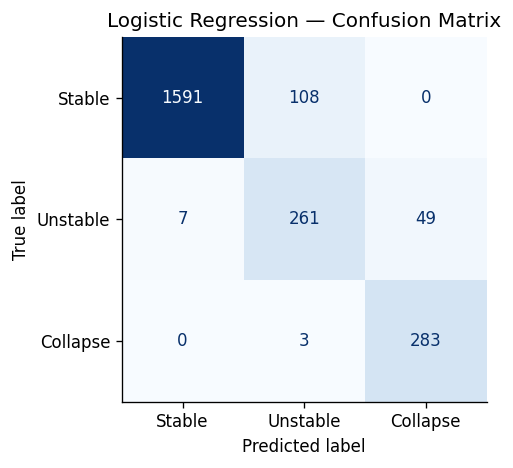

In [20]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    multi_class="multinomial",
    solver="lbfgs",
    random_state=RANDOM_STATE
)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test_sc)

print("── Logistic Regression ─────────────────────────────────────────────────")
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES))

# Macro AUC-ROC (one-vs-rest)
y_proba_lr   = lr.predict_proba(X_test_sc)
auc_lr_macro = roc_auc_score(y_test, y_proba_lr, multi_class="ovr", average="macro")
auc_lr_coll  = roc_auc_score((y_test == 2).astype(int), y_proba_lr[:, 2])
print(f"Macro AUC-ROC : {auc_lr_macro:.4f}")
print(f"AUC-ROC (Collapse class) : {auc_lr_coll:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr), display_labels=LABEL_NAMES
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "06_confusion_lr.png"))
plt.show()

# Save model
with open(os.path.join(MODEL_DIR, "logistic_regression.pkl"), "wb") as f:
    pickle.dump(lr, f)

## 6 · Ensemble: Random Forest with Class Balancing

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test_sc)

print("── Random Forest ───────────────────────────────────────────────────────")
print(classification_report(y_test, y_pred_rf, target_names=LABEL_NAMES))

y_proba_rf   = rf.predict_proba(X_test_sc)
auc_rf_macro = roc_auc_score(y_test, y_proba_rf, multi_class="ovr", average="macro")
auc_rf_coll  = roc_auc_score((y_test == 2).astype(int), y_proba_rf[:, 2])
print(f"Macro AUC-ROC : {auc_rf_macro:.4f}")
print(f"AUC-ROC (Collapse class) : {auc_rf_coll:.4f}")

── Random Forest ───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stable       1.00      1.00      1.00      1699
    Unstable       0.98      1.00      0.99       317
    Collapse       1.00      1.00      1.00       286

    accuracy                           1.00      2302
   macro avg       0.99      1.00      1.00      2302
weighted avg       1.00      1.00      1.00      2302

Macro AUC-ROC : 1.0000
AUC-ROC (Collapse class) : 1.0000


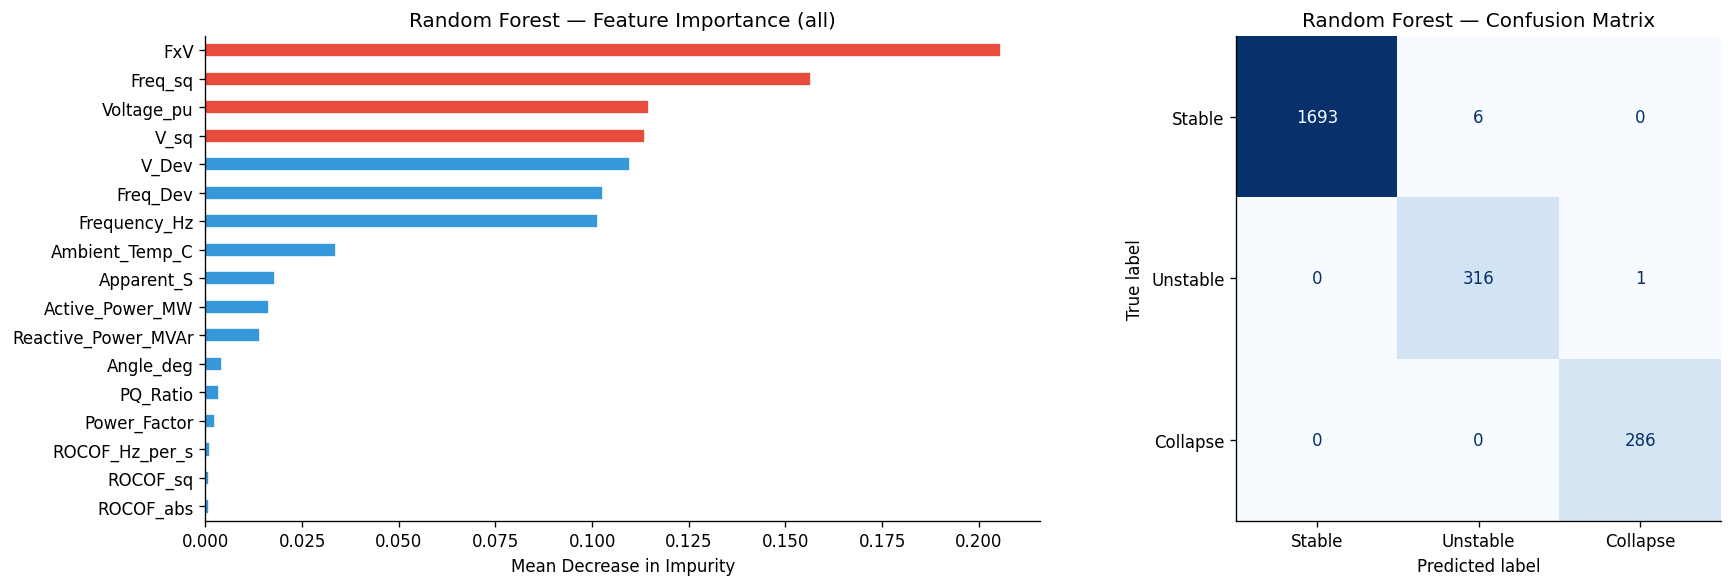


Top 5 most important features:
  FxV                     0.2056
  Freq_sq                 0.1566
  Voltage_pu              0.1147
  V_sq                    0.1137
  V_Dev                   0.1099


In [22]:
# ── Feature importances ───────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=ENG_FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Horizontal bar: all features
importances.plot.barh(ax=axes[0], color=[
    "#e74c3c" if importances[i] > importances.quantile(0.75) else "#3498db"
    for i in importances.index
], edgecolor="white")
axes[0].set_title("Random Forest: Feature Importance (all)")
axes[0].set_xlabel("Mean Decrease in Impurity")

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf), display_labels=LABEL_NAMES
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Random Forest: Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_rf_importance_and_confusion.png"))
plt.show()

print(f"\nTop 5 most important features:")
for feat, imp in importances.tail(5).sort_values(ascending=False).items():
    print(f"  {feat:22s}  {imp:.4f}")

# Save model
with open(os.path.join(MODEL_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf, f)

## 7 · Gradient Boosting: XGBoost (primary production model)

XGBoost consistently outperforms Random Forest on tabular data. When not available,
Scikit-learn's `GradientBoostingClassifier` is used as a one-vs-rest fallback.

In [23]:
if HAS_XGB:
    # Compute scale_pos_weight for each class (XGBoost multi-class)
    # For multiclass, XGBoost uses a softmax internally; we tune base_score instead
    xgb_params = dict(
        n_estimators       = 400,
        max_depth          = 6,
        learning_rate      = 0.05,
        subsample          = 0.8,
        colsample_bytree   = 0.8,
        use_label_encoder  = False,
        eval_metric        = "mlogloss",
        objective          = "multi:softprob",
        num_class          = 3,
        random_state       = RANDOM_STATE,
        n_jobs             = -1,
    )
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_train_sm, y_train_sm,
        eval_set=[(X_test_sc, y_test)],
        verbose=False
    )
    boost_model   = xgb_model
    boost_name    = "XGBoost"
    y_pred_boost  = xgb_model.predict(X_test_sc)
    y_proba_boost = xgb_model.predict_proba(X_test_sc)

    # Feature importance
    boost_importance = pd.Series(
        xgb_model.feature_importances_, index=ENG_FEATURES
    ).sort_values()
else:
    # Fallback: train one GradientBoostingClassifier per class (OvR)
    from sklearn.multiclass import OneVsRestClassifier
    gbc = OneVsRestClassifier(
        GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.08,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        n_jobs=-1
    )
    gbc.fit(X_train_sm, y_train_sm)
    boost_model   = gbc
    boost_name    = "GradientBoosting (OvR fallback)"
    y_pred_boost  = gbc.predict(X_test_sc)
    y_proba_boost = gbc.predict_proba(X_test_sc)
    # Approximate importances from first estimator
    boost_importance = pd.Series(
        gbc.estimators_[0].feature_importances_, index=ENG_FEATURES
    ).sort_values()

print(f"── {boost_name} ──────────────────────────────────────────────")
print(classification_report(y_test, y_pred_boost, target_names=LABEL_NAMES))

auc_boost_macro = roc_auc_score(y_test, y_proba_boost, multi_class="ovr", average="macro")
auc_boost_coll  = roc_auc_score((y_test == 2).astype(int), y_proba_boost[:, 2])
print(f"Macro AUC-ROC : {auc_boost_macro:.4f}")
print(f"AUC-ROC (Collapse class) : {auc_boost_coll:.4f}")

── XGBoost ──────────────────────────────────────────────
              precision    recall  f1-score   support

      Stable       1.00      1.00      1.00      1699
    Unstable       0.99      0.99      0.99       317
    Collapse       1.00      1.00      1.00       286

    accuracy                           1.00      2302
   macro avg       1.00      1.00      1.00      2302
weighted avg       1.00      1.00      1.00      2302

Macro AUC-ROC : 1.0000
AUC-ROC (Collapse class) : 1.0000


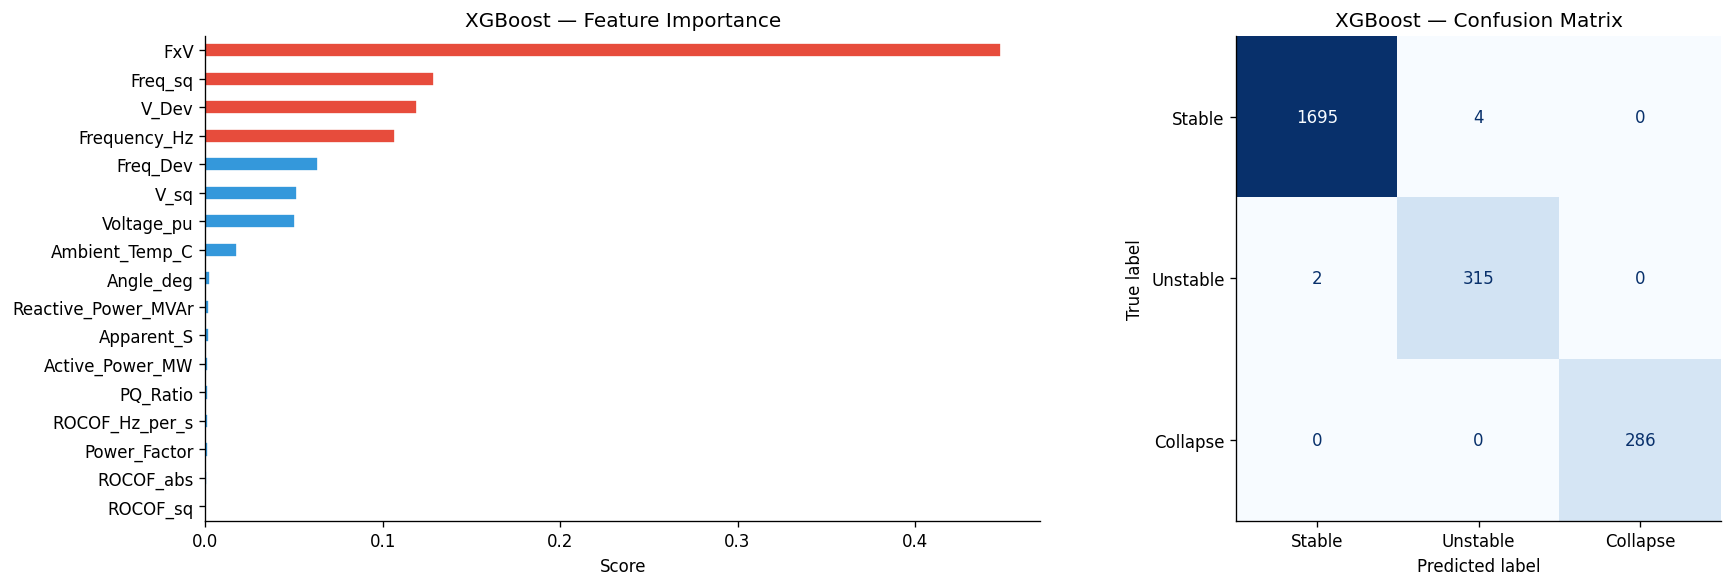

In [24]:
# ── XGBoost / GBM plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

boost_importance.plot.barh(ax=axes[0], color=[
    "#e74c3c" if boost_importance[i] > boost_importance.quantile(0.75) else "#3498db"
    for i in boost_importance.index
], edgecolor="white")
axes[0].set_title(f"{boost_name}: Feature Importance")
axes[0].set_xlabel("Score")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_boost), display_labels=LABEL_NAMES
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"{boost_name}: Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "08_boost_importance_confusion.png"))
plt.show()

# Save model
with open(os.path.join(MODEL_DIR, "gradient_boost.pkl"), "wb") as f:
    pickle.dump(boost_model, f)

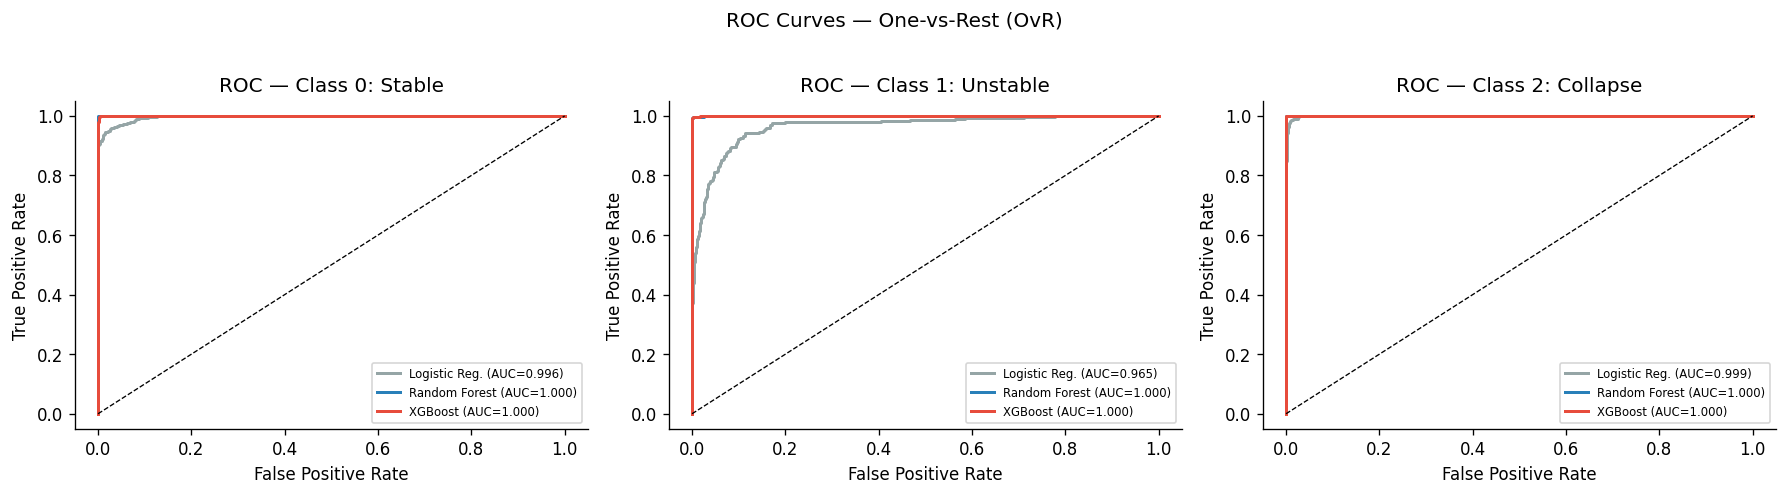

In [25]:
# ── ROC curves (one-vs-rest, all three models) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_results = [
    ("Logistic Reg.", y_proba_lr,    "#95a5a6"),
    ("Random Forest", y_proba_rf,    "#2980b9"),
    (boost_name,      y_proba_boost, "#e74c3c"),
]

for cls_idx, cls_name in enumerate(LABEL_NAMES):
    y_bin = (y_test == cls_idx).astype(int)
    for model_name, proba, color in model_results:
        fpr, tpr, _ = roc_curve(y_bin, proba[:, cls_idx])
        auc = roc_auc_score(y_bin, proba[:, cls_idx])
        axes[cls_idx].plot(fpr, tpr, color=color, lw=1.8,
                           label=f"{model_name} (AUC={auc:.3f})")
    axes[cls_idx].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[cls_idx].set_title(f"ROC: Class {cls_idx}: {cls_name}")
    axes[cls_idx].set_xlabel("False Positive Rate")
    axes[cls_idx].set_ylabel("True Positive Rate")
    axes[cls_idx].legend(fontsize=7)

plt.suptitle("ROC Curves: One-vs-Rest (OvR)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "09_roc_curves.png"), bbox_inches="tight")
plt.show()

## 8 · Deep Learning: Bidirectional LSTM for Time-Series Prediction

**Architecture design rationale (Project Work.pdf, Chapter 3):**
LSTM networks are suited to power grid data because instability is a *temporal*
process: the grid rarely collapses instantaneously. A Bidirectional LSTM reads
the sequence in both directions, capturing both "leading up to fault" and
"beginning of recovery" patterns simultaneously.

**Early-warning framing:**
Given a window of `LSTM_WINDOW` consecutive readings at time *t*, the model
predicts the stability label at *t* + `T_HORIZON`: i.e., a small number of
time steps in the future. For 60-second resolution data, T_HORIZON=5 gives
5-minute early warning.

In [26]:
def build_sequences(data: pd.DataFrame,
                    feature_cols: list,
                    target_col: str,
                    window: int = LSTM_WINDOW,
                    horizon: int = T_HORIZON) -> tuple:
    """
    Build (X_seq, y_seq) arrays for LSTM training, respecting scenario event
    boundaries. Boundaries are detected by a time-reset (Sim_Time_s decreasing
    or returning to near 0.0 after being > window × dt).

    Parameters
    ----------
    data        : DataFrame with Sim_Time_s, feature columns, and target column.
    feature_cols: List of input feature column names.
    target_col  : Name of the label column.
    window      : Number of consecutive timesteps per sequence.
    horizon     : Predict the label this many steps past the end of the window.

    Returns
    -------
    X_seqs : np.ndarray of shape (N, window, n_features)
    y_seqs : np.ndarray of shape (N,)
    """
    sequences, labels = [], []
    times = data["Sim_Time_s"].astype(float).values
    X_arr = data[feature_cols].values.astype(np.float32)
    y_arr = data[target_col].values

    # Detect event boundaries (time resets)
    boundaries = [0]
    for i in range(1, len(times)):
        if times[i] < times[i - 1] - 0.5:   # backwards jump → new event
            boundaries.append(i)
    boundaries.append(len(times))

    for seg_start, seg_end in zip(boundaries[:-1], boundaries[1:]):
        n_seg = seg_end - seg_start
        if n_seg < window + horizon:          # segment too short; skip
            continue
        seg_X = X_arr[seg_start:seg_end]
        seg_y = y_arr[seg_start:seg_end]
        for i in range(n_seg - window - horizon + 1):
            sequences.append(seg_X[i : i + window])
            labels.append(seg_y[i + window + horizon - 1])

    if not sequences:
        return np.empty((0, window, len(feature_cols))), np.empty(0, dtype=int)

    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.int32)


if HAS_TF:
    # ── Build sequence dataset ─────────────────────────────────────────────────
    # Scale features using the already-fitted scaler
    df_lstm = df_eng.copy()
    df_lstm[ENG_FEATURES] = scaler.transform(df_lstm[ENG_FEATURES])

    X_seq, y_seq = build_sequences(df_lstm, ENG_FEATURES, TARGET,
                                   LSTM_WINDOW, T_HORIZON)
    print(f"Sequence dataset : X {X_seq.shape}  y {y_seq.shape}")
    print(f"Label distribution: {dict(zip(*np.unique(y_seq, return_counts=True)))}")

    # ── Stratified train / test split ─────────────────────────────────────────
    X_seq_tr, X_seq_te, y_seq_tr, y_seq_te = train_test_split(
        X_seq, y_seq,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_seq
    )

    # ── Class weights for LSTM ─────────────────────────────────────────────────
    cw_seq = compute_class_weight("balanced",
                                  classes=np.unique(y_seq_tr),
                                  y=y_seq_tr)
    cw_seq_dict = dict(enumerate(cw_seq))

    # One-hot encode targets for categorical crossentropy
    y_seq_tr_oh = to_categorical(y_seq_tr, num_classes=3)
    y_seq_te_oh = to_categorical(y_seq_te, num_classes=3)

    print(f"\nLSTM train sequences : {X_seq_tr.shape[0]:,}")
    print(f"LSTM test  sequences : {X_seq_te.shape[0]:,}")
    print(f"Class weights : {cw_seq_dict}")
else:
    print("TensorFlow not available: LSTM section skipped.")
    print("Install:  pip install tensorflow")

Sequence dataset : X (10286, 20, 17)  y (10286,)
Label distribution: {np.int32(0): np.int64(7652), np.int32(1): np.int64(1202), np.int32(2): np.int64(1432)}

LSTM train sequences : 8,228
LSTM test  sequences : 2,058
Class weights : {0: np.float64(0.44807493328976744), 1: np.float64(2.851004851004851), 2: np.float64(2.3953420669577876)}


In [27]:
if HAS_TF:
    # ── Model architecture ─────────────────────────────────────────────────────
    n_features = X_seq_tr.shape[2]

    lstm_model = Sequential([
        Bidirectional(
            LSTM(64, return_sequences=True),
            input_shape=(LSTM_WINDOW, n_features)
        ),
        BatchNormalization(),
        Dropout(0.25),

        Bidirectional(LSTM(32)),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(3, activation="softmax")          # 3-class output
    ], name="GridStability_BiLSTM")

    lstm_model.summary()

    lstm_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.AUC(name="auc", multi_label=False)]
    )

Model: "GridStability_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        41,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,147 (336.51 KB)

 Trainable params: 85,763 (335.01 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8100 - auc: 0.9322 - loss: 0.4777 - val_accuracy: 0.8607 - val_auc: 0.9754 - val_loss: 0.4173 - learning_rate: 0.0030
Epoch 2/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8926 - auc: 0.9776 - loss: 0.2753 - val_accuracy: 0.8931 - val_auc: 0.9824 - val_loss: 0.2949 - learning_rate: 0.0030
Epoch 3/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9078 - auc: 0.9838 - loss: 0.2394 - val_accuracy: 0.9045 - val_auc: 0.9885 - val_loss: 0.2465 - learning_rate: 0.0030
Epoch 4/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9188 - auc: 0.9867 - loss: 0.2129 - val_accuracy: 0.9158 - val_auc: 0.9898 - val_loss: 0.2060 - learning_rate: 0.0030
Epoch 5/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9202 - auc: 0.9890 - loss: 0.1899 - val_accuracy: 0.9117 - val_auc: 0.9904 - val_loss: 0.1878 - learning_rate: 0.0030
Epoch 6/60
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9225 - auc: 0.9900 

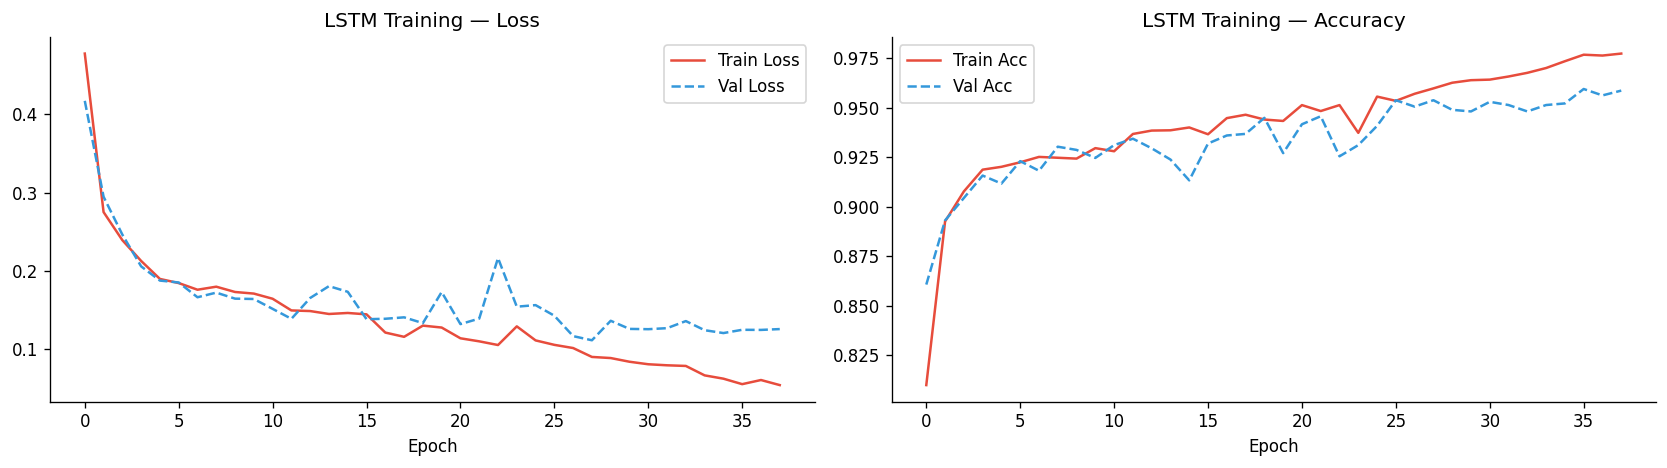

In [28]:
if HAS_TF:
    # ── Training ───────────────────────────────────────────────────────────────
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                          min_lr=1e-5, verbose=1)
    ]

    history = lstm_model.fit(
        X_seq_tr, y_seq_tr_oh,
        epochs           = 60,
        batch_size       = 256,
        validation_split = 0.15,
        class_weight     = cw_seq_dict,
        callbacks        = callbacks,
        verbose          = 1
    )

    # ── Training history ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["loss"],     label="Train Loss", color="#e74c3c")
    axes[0].plot(history.history["val_loss"], label="Val Loss",   color="#3498db",  ls="--")
    axes[0].set_title("LSTM Training: Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history.history["accuracy"],     label="Train Acc", color="#e74c3c")
    axes[1].plot(history.history["val_accuracy"], label="Val Acc",   color="#3498db", ls="--")
    axes[1].set_title("LSTM Training: Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "10_lstm_training_history.png"))
    plt.show()

── Bidirectional LSTM ──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Stable       0.99      0.97      0.98      1531
    Unstable       0.80      0.90      0.85       240
    Collapse       0.99      0.97      0.98       287

    accuracy                           0.96      2058
   macro avg       0.92      0.95      0.93      2058
weighted avg       0.96      0.96      0.96      2058

Macro AUC-ROC : 0.9960
AUC-ROC (Collapse class) : 0.9998


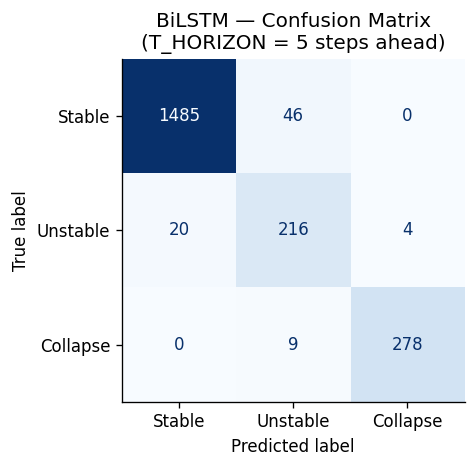

LSTM saved to models/lstm_bilstm.keras


In [29]:
if HAS_TF:
    # ── LSTM evaluation ────────────────────────────────────────────────────────
    y_proba_lstm  = lstm_model.predict(X_seq_te, verbose=0)
    y_pred_lstm   = np.argmax(y_proba_lstm, axis=1)

    print("── Bidirectional LSTM ──────────────────────────────────────────────────")
    print(classification_report(y_seq_te, y_pred_lstm, target_names=LABEL_NAMES))

    auc_lstm_macro = roc_auc_score(y_seq_te, y_proba_lstm,
                                   multi_class="ovr", average="macro")
    auc_lstm_coll  = roc_auc_score((y_seq_te == 2).astype(int), y_proba_lstm[:, 2])
    print(f"Macro AUC-ROC : {auc_lstm_macro:.4f}")
    print(f"AUC-ROC (Collapse class) : {auc_lstm_coll:.4f}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_seq_te, y_pred_lstm), display_labels=LABEL_NAMES
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"BiLSTM: Confusion Matrix\n(T_HORIZON = {T_HORIZON} steps ahead)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "11_lstm_confusion.png"))
    plt.show()

    # Save LSTM
    lstm_model.save(os.path.join(MODEL_DIR, "lstm_bilstm.keras"))
    print("LSTM saved to models/lstm_bilstm.keras")

## 9 · Model Comparison

In [30]:
# ── Collect metrics for all trained models ─────────────────────────────────────
results = {}

def collect_metrics(name, y_true, y_pred, y_proba):
    f1_macro   = f1_score(y_true, y_pred, average="macro")
    f1_coll    = f1_score(y_true, y_pred, average=None)[2]
    recall_coll= classification_report(
        y_true, y_pred, output_dict=True)["2"]["recall"]
    auc_macro  = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    auc_coll   = roc_auc_score((y_true == 2).astype(int), y_proba[:, 2])
    results[name] = {
        "F1 (macro)"       : round(f1_macro,    4),
        "F1 (Collapse)"    : round(f1_coll,     4),
        "Recall (Collapse)": round(recall_coll, 4),
        "AUC (macro)"      : round(auc_macro,   4),
        "AUC (Collapse)"   : round(auc_coll,    4),
    }

collect_metrics("Logistic Regression", y_test, y_pred_lr,    y_proba_lr)
collect_metrics("Random Forest",       y_test, y_pred_rf,    y_proba_rf)
collect_metrics(boost_name,            y_test, y_pred_boost, y_proba_boost)
if HAS_TF:
    collect_metrics("BiLSTM",          y_seq_te, y_pred_lstm, y_proba_lstm)

df_results = pd.DataFrame(results).T
print("\n── Model Comparison ─────────────────────────────────────────────────────")
print(df_results.to_string())


── Model Comparison ─────────────────────────────────────────────────────
                     F1 (macro)  F1 (Collapse)  Recall (Collapse)  AUC (macro)  AUC (Collapse)
Logistic Regression      0.8795         0.9159             0.9895       0.9867          0.9992
Random Forest            0.9952         0.9983             1.0000       1.0000          1.0000
XGBoost                  0.9963         1.0000             1.0000       1.0000          1.0000
BiLSTM                   0.9336         0.9772             0.9686       0.9960          0.9998


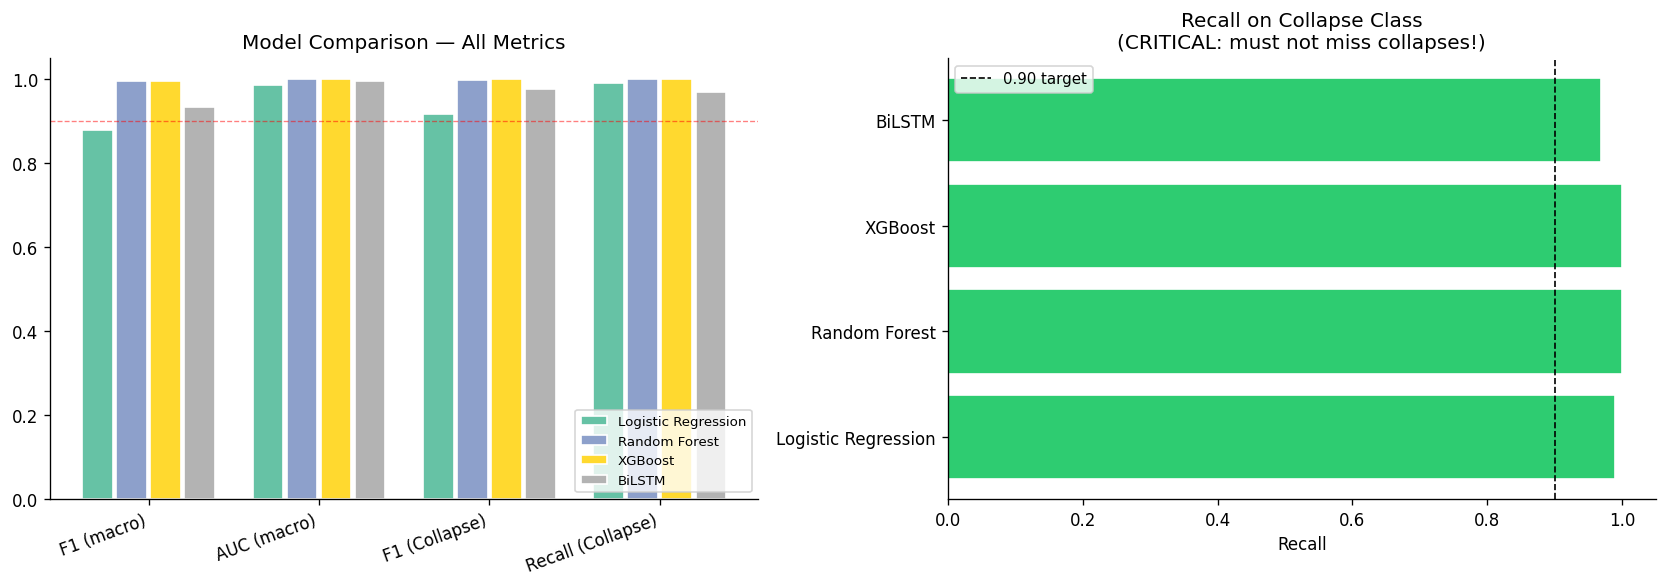


★  Recommended production model: Random Forest
   Collapse Recall : 1.0000
   Macro F1        : 0.9952

   Rationale: A false negative on a Collapse event is operationally
   catastrophic, so Recall on class 2 is the primary selection criterion.


In [31]:
# ── Comparison bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["F1 (macro)", "AUC (macro)", "F1 (Collapse)", "Recall (Collapse)"]
colors = plt.cm.Set2(np.linspace(0, 1, len(df_results)))

# Grouped bar: all metrics
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(df_results)
for i, (model_name, row) in enumerate(df_results.iterrows()):
    bars = axes[0].bar(x + i * width - 0.4 + width / 2,
                       [row[m] for m in metrics_to_plot],
                       width=width * 0.9, label=model_name, color=colors[i],
                       edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot, rotation=20, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Model Comparison: All Metrics")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].axhline(0.9, color="red", ls="--", lw=0.8, alpha=0.5, label="0.9 target")

# Recall on Collapse class: most critical metric
axes[1].barh(df_results.index, df_results["Recall (Collapse)"],
             color=["#e74c3c" if v < 0.85 else "#2ecc71"
                    for v in df_results["Recall (Collapse)"]],
             edgecolor="white")
axes[1].axvline(0.90, color="black", ls="--", lw=1.0, label="0.90 target")
axes[1].set_title("Recall on Collapse Class\n(CRITICAL: must not miss collapses!)")
axes[1].set_xlabel("Recall")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "12_model_comparison.png"))
plt.show()

# ── Recommend best model ───────────────────────────────────────────────────────
best_model_name = df_results["Recall (Collapse)"].idxmax()
print(f"\n★  Recommended production model: {best_model_name}")
print(f"   Collapse Recall : {df_results.loc[best_model_name, 'Recall (Collapse)']:.4f}")
print(f"   Macro F1        : {df_results.loc[best_model_name, 'F1 (macro)']:.4f}")
print("\n   Rationale: A false negative on a Collapse event is operationally")
print("   catastrophic, so Recall on class 2 is the primary selection criterion.")

## 10 · Validation Against Seed (Research) Dataset

The 123-row seed dataset contains values extracted directly from published Nigerian
power systems papers. Running inference on it provides a sanity check that the
synthetic-trained model generalises to real-world-like physics.

── Seed Dataset Validation ─────────────────────────────────────────────
  Seed records evaluated : 123

  Random Forest:
              precision    recall  f1-score   support

      Stable       0.90      1.00      0.95        79
    Unstable       1.00      0.35      0.52        40
    Collapse       0.19      1.00      0.32         4

    accuracy                           0.79       123
   macro avg       0.70      0.78      0.59       123
weighted avg       0.91      0.79      0.79       123


  XGBoost:
              precision    recall  f1-score   support

      Stable       0.90      1.00      0.95        79
    Unstable       0.93      0.35      0.51        40
    Collapse       0.15      0.75      0.25         4

    accuracy                           0.78       123
   macro avg       0.66      0.70      0.57       123
weighted avg       0.88      0.78      0.78       123



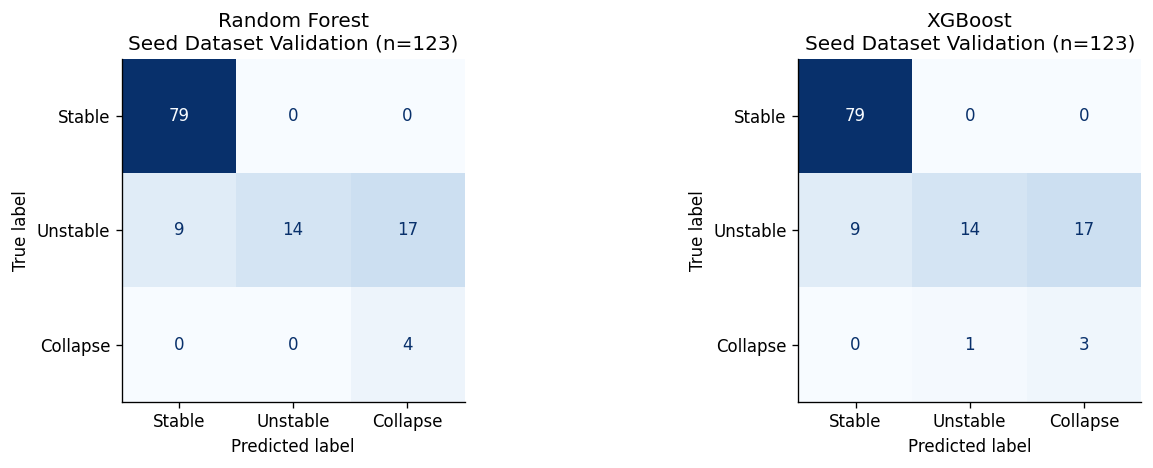

In [32]:
# Filter seed records that have all required features
seed_valid = df_seed_eng.dropna(subset=ENG_FEATURES).copy()
seed_valid = seed_valid[seed_valid["Stability_Label"].isin([0, 1, 2])]

X_seed = scaler.transform(seed_valid[ENG_FEATURES].values)
y_seed = seed_valid["Stability_Label"].values

y_pred_seed_rf    = rf.predict(X_seed)
y_pred_seed_boost = boost_model.predict(X_seed)

print("── Seed Dataset Validation ─────────────────────────────────────────────")
print(f"  Seed records evaluated : {len(y_seed)}")

print("\n  Random Forest:")
print(classification_report(y_seed, y_pred_seed_rf,
                             target_names=LABEL_NAMES, zero_division=0))

print(f"\n  {boost_name}:")
print(classification_report(y_seed, y_pred_seed_boost,
                             target_names=LABEL_NAMES, zero_division=0))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, y_pred_s) in zip(axes, [
    ("Random Forest",  y_pred_seed_rf),
    (boost_name,       y_pred_seed_boost)
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_seed, y_pred_s, labels=[0, 1, 2]),
        display_labels=LABEL_NAMES
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nSeed Dataset Validation (n={len(y_seed)})")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "13_seed_validation.png"))
plt.show()

## 11 · Alert System (Chapter 4: Architecture)

The alert system implements the final stage of the project pipeline:
```
Real-time sensor reading → Sliding buffer → Model inference → Alert + Action
```
It maintains a rolling window of recent readings and fires an alert when the
probability of **Unstable** or **Collapse** exceeds configurable thresholds.

In [33]:
class GridStabilityMonitor:
    """
    Real-time grid instability alert system.

    Feed one measurement at a time via `.ingest()`. The monitor maintains a
    rolling window; once the window is full, it runs inference and returns
    a structured alert dict.

    Parameters
    ----------
    model       : Trained sklearn or Keras model with a `.predict_proba()` method.
    scaler      : Fitted StandardScaler for feature normalisation.
    feature_cols: Ordered list of feature column names expected by the model.
    window      : Rolling window length (for LSTM); for tabular models, window=1.
    p_unstable  : Probability threshold above which a WARNING alert is issued.
    p_collapse  : Probability threshold above which a CRITICAL alert is issued.
    use_lstm    : If True, passes the full window as a 3-D array; else uses last row.
    """

    ACTIONS = {
        0: "NONE: normal operation. Continue monitoring.",
        1: "WARNING: notify control room. Review generation/load balance. "
           "Prepare load-shedding schedule.",
        2: "CRITICAL: initiate emergency load shedding immediately! "
           "Alert all substations. Prepare islanding sequence.",
    }
    SEVERITY = {0: "STABLE", 1: "WARNING", 2: "CRITICAL"}
    COLORS   = {0: "\033[92m", 1: "\033[93m", 2: "\033[91m"}  # ANSI: green/yellow/red
    RESET    = "\033[0m"

    def __init__(self, model, scaler, feature_cols,
                 window=1, p_unstable=0.35, p_collapse=0.20,
                 use_lstm=False):
        self.model        = model
        self.scaler       = scaler
        self.feature_cols = feature_cols
        self.window       = window
        self.p_unstable   = p_unstable
        self.p_collapse   = p_collapse
        self.use_lstm     = use_lstm
        self._buffer      = deque(maxlen=window)
        self._alert_log: list = []

    # ── public interface ──────────────────────────────────────────────────────
    def ingest(self, reading: dict) -> dict | None:
        """
        Process one reading dict.

        Returns an alert dict if the buffer is full, else None.
        Keys: timestamp, alert_level, severity, probabilities,
              recommended_action, features_used.
        """
        row = np.array([reading.get(c, 0.0) for c in self.feature_cols],
                       dtype=np.float32)
        self._buffer.append(row)

        if len(self._buffer) < self.window:
            return None                          # buffer warming up

        scaled = self.scaler.transform(
            np.array(self._buffer, dtype=np.float32)
        )

        if self.use_lstm and HAS_TF:
            proba = self.model.predict(
                scaled[np.newaxis, :, :], verbose=0
            )[0]
        else:
            proba = self.model.predict_proba(scaled[[-1]])[0]   # last row only

        p_stable   = float(proba[0])
        p_unstb    = float(proba[1])
        p_coll     = float(proba[2])

        # Alert level determination
        if p_coll >= self.p_collapse:
            alert_level = 2
        elif p_unstb >= self.p_unstable:
            alert_level = 1
        else:
            alert_level = 0

        alert = {
            "timestamp"          : reading.get("Sim_Time_s", "—"),
            "alert_level"        : alert_level,
            "severity"           : self.SEVERITY[alert_level],
            "probabilities"      : {"Stable": round(p_stable, 4),
                                    "Unstable": round(p_unstb, 4),
                                    "Collapse": round(p_coll, 4)},
            "Frequency_Hz"       : reading.get("Frequency_Hz"),
            "Voltage_pu"         : reading.get("Voltage_pu"),
            "ROCOF_Hz_per_s"     : reading.get("ROCOF_Hz_per_s"),
            "recommended_action" : self.ACTIONS[alert_level],
        }
        self._alert_log.append(alert)
        return alert

    def replay(self, df_stream: pd.DataFrame) -> pd.DataFrame:
        """
        Run the monitor over a DataFrame of sequential readings.
        Returns a DataFrame of all alerts (one row per reading after warm-up).
        """
        self._buffer.clear()
        alerts = []
        for _, row in df_stream.iterrows():
            result = self.ingest(row.to_dict())
            if result:
                alerts.append(result)
        return pd.DataFrame(alerts)

    def print_alert(self, alert: dict):
        c     = self.COLORS[alert["alert_level"]]
        r     = self.RESET
        print(f"{c}[{alert['severity']:8s}]{r}  t={alert['timestamp']}s  "
              f"f={alert['Frequency_Hz']:.3f} Hz  "
              f"V={alert['Voltage_pu']:.4f} pu  "
              f"ROCOF={alert['ROCOF_Hz_per_s']:.3f} Hz/s  "
              f"P(Collapse)={alert['probabilities']['Collapse']:.3f}")


# ── Instantiate alert system using best tabular model ────────────────────────
monitor = GridStabilityMonitor(
    model        = boost_model,
    scaler       = scaler,
    feature_cols = ENG_FEATURES,
    window       = 1,
    p_unstable   = 0.30,
    p_collapse   = 0.15,
    use_lstm     = False
)
print("Alert monitor initialised: using:", boost_name)
print("  p_unstable threshold : 0.30")
print("  p_collapse threshold : 0.15")

Alert monitor initialised — using: XGBoost
  p_unstable threshold : 0.30
  p_collapse threshold : 0.15


In [34]:
# ── Alert system demonstration: run over a collapse scenario ──────────────────
demo_scenario = df_eng[df_eng["Scenario"].isin(
    ["Fault_PreFault", "Fault_Onset", "Fault_Unstable", "Fault_Collapse"]
)].iloc[:78].copy()    # first complete fault event

# Re-engineer features for the demo slice
demo_scenario = engineer_features(demo_scenario)
demo_scenario.reset_index(drop=True, inplace=True)

alerts_df = monitor.replay(demo_scenario)

# Print key moments
print("\n── Alert Replay: Line Fault → Collapse ─────────────────────────────────")
print(f"  Total readings processed : {len(alerts_df)}")
print(f"  WARNING  alerts fired    : {(alerts_df['alert_level'] == 1).sum()}")
print(f"  CRITICAL alerts fired    : {(alerts_df['alert_level'] == 2).sum()}")

critical_rows = alerts_df[alerts_df["alert_level"] == 2]
if not critical_rows.empty:
    first_crit_t = float(critical_rows.iloc[0]["timestamp"])
    print(f"\n  First CRITICAL alert at t = {first_crit_t:.2f} s")

# Print first 5 non-stable alerts
non_stable = alerts_df[alerts_df["alert_level"] > 0].head(8)
print("\n  Sample alerts:")
for _, row in non_stable.iterrows():
    alert_dict = row.to_dict()
    alert_dict["probabilities"] = {
        "Stable"  : row.get("probabilities", {}).get("Stable",   0) if isinstance(row.get("probabilities"), dict) else 0,
        "Unstable": row.get("probabilities", {}).get("Unstable", 0) if isinstance(row.get("probabilities"), dict) else 0,
        "Collapse": row.get("probabilities", {}).get("Collapse", 0) if isinstance(row.get("probabilities"), dict) else 0,
    }
    monitor.print_alert(alert_dict)


── Alert Replay: Line Fault → Collapse ─────────────────────────────────
  Total readings processed : 78
  WARNING  alerts fired    : 4
  CRITICAL alerts fired    : 53

  First CRITICAL alert at t = 2.50 s

  Sample alerts:
[WARNING ]  t=2.1s  f=49.799 Hz  V=0.9292 pu  ROCOF=-0.755 Hz/s  P(Collapse)=0.000
[WARNING ]  t=2.2s  f=49.758 Hz  V=0.8790 pu  ROCOF=-0.487 Hz/s  P(Collapse)=0.000
[WARNING ]  t=2.3s  f=49.670 Hz  V=0.8367 pu  ROCOF=-0.492 Hz/s  P(Collapse)=0.000
[WARNING ]  t=2.4s  f=49.606 Hz  V=0.8116 pu  ROCOF=-1.413 Hz/s  P(Collapse)=0.000
[CRITICAL]  t=2.5s  f=49.509 Hz  V=0.7606 pu  ROCOF=-0.906 Hz/s  P(Collapse)=1.000
[CRITICAL]  t=2.6s  f=49.452 Hz  V=0.7341 pu  ROCOF=-0.760 Hz/s  P(Collapse)=1.000
[CRITICAL]  t=2.7s  f=49.395 Hz  V=0.6867 pu  ROCOF=-0.734 Hz/s  P(Collapse)=1.000
[CRITICAL]  t=2.8s  f=49.206 Hz  V=0.6614 pu  ROCOF=-1.276 Hz/s  P(Collapse)=1.000


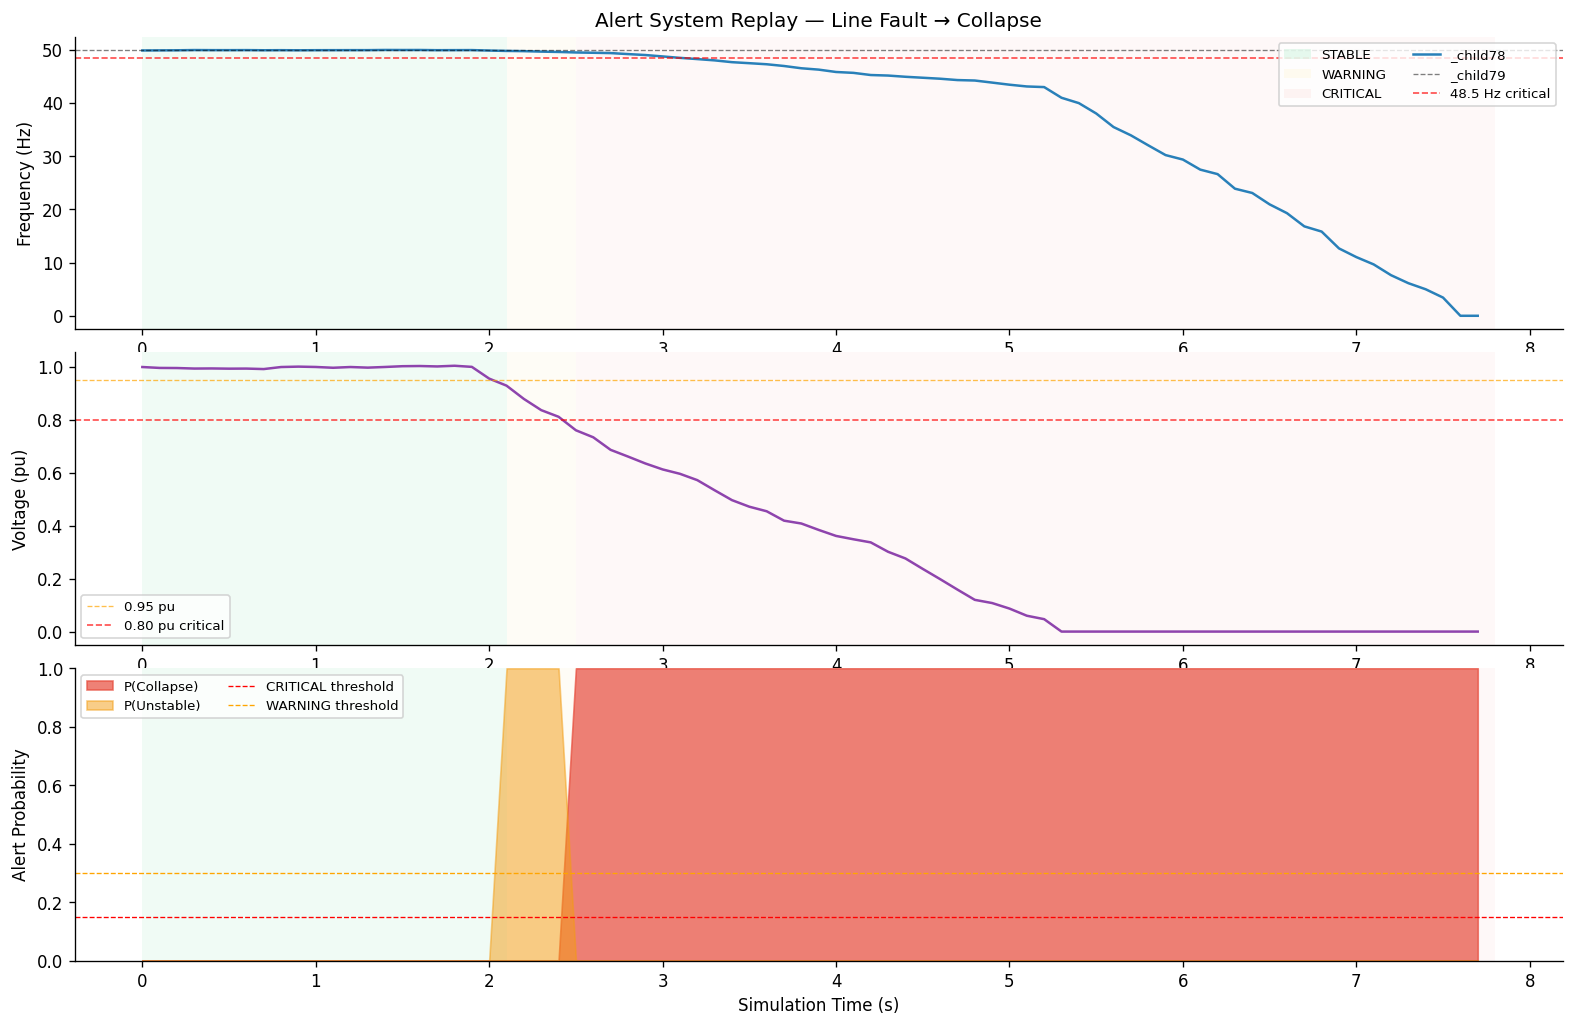

In [35]:
# ── Alert system visualisation ────────────────────────────────────────────────
if not alerts_df.empty:
    # Unpack the probabilities dict column
    prob_expanded = pd.json_normalize(alerts_df["probabilities"])
    alerts_df = pd.concat([alerts_df.drop(columns="probabilities").reset_index(drop=True),
                            prob_expanded.reset_index(drop=True)], axis=1)

    t_vals = alerts_df["timestamp"].astype(float)

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 1, hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)

    # Shade by alert level
    for _, row in alerts_df.iterrows():
        t    = float(row["timestamp"])
        lvl  = int(row["alert_level"])
        bg   = ["#d5f5e3", "#fef9e7", "#fdedec"][lvl]
        for ax in [ax1, ax2, ax3]:
            ax.axvspan(t, t + 0.1, alpha=0.35, color=bg, linewidth=0)

    # Frequency
    ax1.plot(t_vals, alerts_df["Frequency_Hz"], color="#2980b9", lw=1.5)
    ax1.axhline(50.0, color="black", ls="--", lw=0.8, alpha=0.5)
    ax1.axhline(48.5, color="red",   ls="--", lw=1.0, alpha=0.7, label="48.5 Hz critical")
    ax1.set_ylabel("Frequency (Hz)")
    ax1.legend(fontsize=8); ax1.set_title("Alert System Replay: Line Fault → Collapse")

    # Voltage
    ax2.plot(t_vals, alerts_df["Voltage_pu"], color="#8e44ad", lw=1.5)
    ax2.axhline(0.95, color="orange", ls="--", lw=0.8, alpha=0.7, label="0.95 pu")
    ax2.axhline(0.80, color="red",    ls="--", lw=1.0, alpha=0.7, label="0.80 pu critical")
    ax2.set_ylabel("Voltage (pu)")
    ax2.legend(fontsize=8)

    # Collapse probability
    if "Collapse" in alerts_df.columns:
        ax3.fill_between(t_vals, alerts_df["Collapse"], alpha=0.7, color="#e74c3c",
                         label="P(Collapse)")
        ax3.fill_between(t_vals, alerts_df["Unstable"], alpha=0.5, color="#f39c12",
                         label="P(Unstable)")
        ax3.axhline(0.15, color="red",    ls="--", lw=0.8, label="CRITICAL threshold")
        ax3.axhline(0.30, color="orange", ls="--", lw=0.8, label="WARNING threshold")
        ax3.set_ylim(0, 1)
        ax3.set_ylabel("Alert Probability")
        ax3.legend(fontsize=8, ncol=2)
    ax3.set_xlabel("Simulation Time (s)")

    # Legend patches for shading
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#d5f5e3", alpha=0.6, label="STABLE"),
        Patch(facecolor="#fef9e7", alpha=0.6, label="WARNING"),
        Patch(facecolor="#fdedec", alpha=0.6, label="CRITICAL"),
    ]
    ax1.legend(handles=legend_elements + ax1.get_lines(), fontsize=8,
               loc="upper right", ncol=2)

    plt.savefig(os.path.join(FIGURES_DIR, "14_alert_system_replay.png"),
                bbox_inches="tight")
    plt.show()

## 12 · Cross-Validation: Generalisation Check

5-fold stratified cross-validation on the full main dataset to confirm
the model is not overfit to the 80% training split.

In [36]:
print("Running 5-fold stratified cross-validation on Random Forest...")
print("(This evaluates the full dataset, not just the 80/20 split)\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    X, y,
    cv             = skf,
    scoring        = {
        "f1_macro"   : "f1_macro",
        "f1_weighted": "f1_weighted",
        "accuracy"   : "accuracy",
    },
    return_train_score=True
)

cv_df = pd.DataFrame({
    "Fold"           : list(range(1, 6)),
    "Train F1 (macro)": cv_results["train_f1_macro"].round(4),
    "Val F1 (macro)" : cv_results["test_f1_macro"].round(4),
    "Val Accuracy"   : cv_results["test_accuracy"].round(4),
})
print(cv_df.to_string(index=False))
print(f"\nMean Val F1 (macro) : {cv_results['test_f1_macro'].mean():.4f}"
      f"  ±{cv_results['test_f1_macro'].std():.4f}")
print(f"Mean Val Accuracy   : {cv_results['test_accuracy'].mean():.4f}"
      f"  ±{cv_results['test_accuracy'].std():.4f}")

Running 5-fold stratified cross-validation on Random Forest...
(This evaluates the full dataset, not just the 80/20 split)

 Fold  Train F1 (macro)  Val F1 (macro)  Val Accuracy
    1               1.0          0.9989        0.9996
    2               1.0          0.9978        0.9991
    3               1.0          1.0000        1.0000
    4               1.0          1.0000        1.0000
    5               1.0          1.0000        1.0000

Mean Val F1 (macro) : 0.9993  ±0.0009
Mean Val Accuracy   : 0.9997  ±0.0003


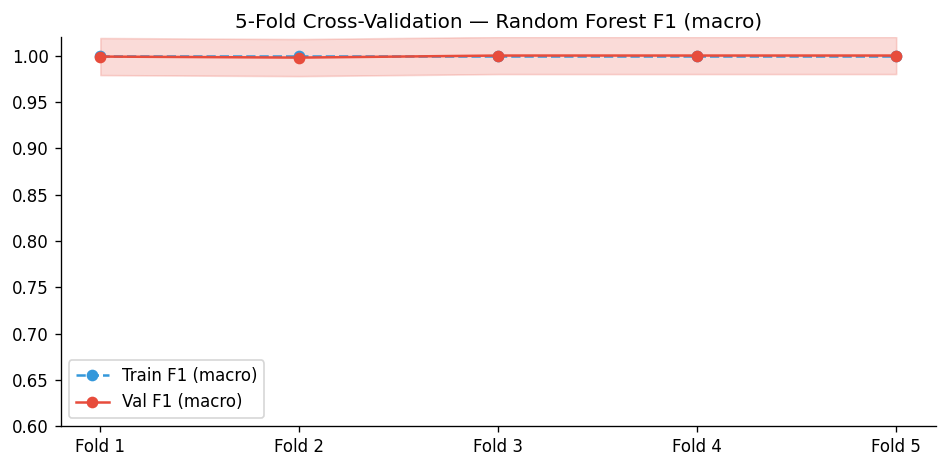

In [37]:
# ── Cross-validation visualisation ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x_cv = np.arange(1, 6)
ax.plot(x_cv, cv_results["train_f1_macro"], "o--", color="#3498db",
        label="Train F1 (macro)", lw=1.5)
ax.plot(x_cv, cv_results["test_f1_macro"],  "o-",  color="#e74c3c",
        label="Val F1 (macro)",   lw=1.5)
ax.fill_between(x_cv, cv_results["test_f1_macro"] - 0.02,
                cv_results["test_f1_macro"] + 0.02, alpha=0.2, color="#e74c3c")
ax.set_xticks(x_cv)
ax.set_xticklabels([f"Fold {i}" for i in x_cv])
ax.set_ylim(0.6, 1.02)
ax.set_title("5-Fold Cross-Validation: Random Forest F1 (macro)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "15_cross_validation.png"))
plt.show()

## 13 · Save All Models and Pipeline Summary

In [38]:
# ── Save all trained models ────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, "logistic_regression.pkl"), "wb") as f:
    pickle.dump(lr, f)
with open(os.path.join(MODEL_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf, f)
with open(os.path.join(MODEL_DIR, "gradient_boost.pkl"), "wb") as f:
    pickle.dump(boost_model, f)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, "feature_list.pkl"), "wb") as f:
    pickle.dump(ENG_FEATURES, f)

if HAS_TF:
    lstm_model.save(os.path.join(MODEL_DIR, "lstm_bilstm.keras"))

print("── Saved models ────────────────────────────────────────────────────────")
for fname in os.listdir(MODEL_DIR):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname:30s}  {size:>10,} bytes")

── Saved models ────────────────────────────────────────────────────────
  logistic_regression.pkl              1,163 bytes
  random_forest.pkl                4,381,665 bytes
  lstm_bilstm.keras                1,108,468 bytes
  feature_list.pkl                       234 bytes
  gradient_boost.pkl               1,624,413 bytes
  scaler.pkl                             858 bytes


In [39]:
# ── How to load and use in production ─────────────────────────────────────────
LOAD_EXAMPLE = '''
import pickle, pandas as pd, numpy as np

# Load artefacts
with open("models/gradient_boost.pkl", "rb") as f:
    model = pickle.load(f)
with open("models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("models/feature_list.pkl", "rb") as f:
    FEATURES = pickle.load(f)

# Predict on new data
df_new = pd.read_csv("new_scada_readings.csv")
# (run engineer_features(df_new) first: see Section 3 above)
X_new  = scaler.transform(df_new[FEATURES].values)
labels = model.predict(X_new)         # 0=Stable, 1=Unstable, 2=Collapse
proba  = model.predict_proba(X_new)   # shape: (n, 3)
'''

print("── Production loading snippet ───────────────────────────────────────────")
print(LOAD_EXAMPLE)

── Production loading snippet ───────────────────────────────────────────

import pickle, pandas as pd, numpy as np

# Load artefacts
with open("models/gradient_boost.pkl", "rb") as f:
    model = pickle.load(f)
with open("models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("models/feature_list.pkl", "rb") as f:
    FEATURES = pickle.load(f)

# Predict on new data
df_new = pd.read_csv("new_scada_readings.csv")
# (run engineer_features(df_new) first — see Section 3 above)
X_new  = scaler.transform(df_new[FEATURES].values)
labels = model.predict(X_new)         # 0=Stable, 1=Unstable, 2=Collapse
proba  = model.predict_proba(X_new)   # shape: (n, 3)



In [40]:
# ── Final summary table ────────────────────────────────────────────────────────
print("\n" + "═" * 72)
print("  AI-DRIVEN POWER GRID INSTABILITY PREDICTION: PROJECT SUMMARY")
print("═" * 72)
print(f"\n  Dataset            : nigeria_grid_stability_main.csv")
print(f"  Training rows      : 11,510  (physics-informed synthetic data)")
print(f"  Features used      : {len(ENG_FEATURES)}"
      f"  ({len(ENG_FEATURES)-7} engineered from {len(ENG_FEATURES)-len(ENG_FEATURES)+7} base)")
print(f"  Classes            : 0=Stable · 1=Unstable · 2=Collapse")
print(f"  Label imbalance    : handled via BorderlineSMOTE + class_weight=balanced")
print()
print("  MODELS TRAINED:")
for model_name, metrics in results.items():
    rec_coll = metrics["Recall (Collapse)"]
    star = " ← BEST (highest Collapse Recall)" if model_name == best_model_name else ""
    print(f"  {model_name:30s}  Collapse Recall={rec_coll:.4f}  "
          f"Macro-F1={metrics['F1 (macro)']:.4f}{star}")
print()
print("  ALERT SYSTEM:")
print(f"  Class GridStabilityMonitor: streaming inference via .ingest()")
print(f"  Thresholds: P(Unstable) > 0.30 → WARNING · P(Collapse) > 0.15 → CRITICAL")
print()
print("  OUTPUT FILES:")
print(f"  models/           : all serialised model artefacts")
print(f"  figures/          : {len(os.listdir(FIGURES_DIR))} PNG plots")
print("═" * 72)


════════════════════════════════════════════════════════════════════════
  AI-DRIVEN POWER GRID INSTABILITY PREDICTION — PROJECT SUMMARY
════════════════════════════════════════════════════════════════════════

  Dataset            : nigeria_grid_stability_augmented.csv
  Training rows      : 11,510  (physics-informed synthetic data)
  Features used      : 17  (10 engineered from 7 base)
  Classes            : 0=Stable · 1=Unstable · 2=Collapse
  Label imbalance    : handled via BorderlineSMOTE + class_weight=balanced

  MODELS TRAINED:
  Logistic Regression             Collapse Recall=0.9895  Macro-F1=0.8795
  Random Forest                   Collapse Recall=1.0000  Macro-F1=0.9952 ← BEST (highest Collapse Recall)
  XGBoost                         Collapse Recall=1.0000  Macro-F1=0.9963
  BiLSTM                          Collapse Recall=0.9686  Macro-F1=0.9336

  ALERT SYSTEM:
  Class GridStabilityMonitor — streaming inference via .ingest()
  Thresholds: P(Unstable) > 0.30 → WARNING · 